<a href="https://colab.research.google.com/github/PriadiCuanda-231401058/Fundamental-Analisis-Data/blob/main/Proyek_Analisis_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: Bike Sharing Dataset (Hour.csv)
- **Nama:** Priadi Cuanda
- **Email:** priadicuanda2904@gmail.com
- **ID Dicoding:** CDCC319D6Y0576

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah total peminjaman sepeda (cnt) pada tahun 2012?
- Pada jam berapa terjadi lonjakan peminjaman sepeda tertinggi pada hari kerja (workingday = 1) dibandingkan hari libur/akhir pekan (workingday = 0)?

## Import Semua Packages/Library yang Digunakan

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [38]:
df = pd.read_csv("https://drive.google.com/uc?id=1NchZqbAKvUYXDUsPrhZASlM4M1uv-w7V")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

Ukuran Data: Dataset yang berhasil dimuat (hour.csv) memiliki dimensi yang cukup besar, yaitu 17.379 baris observasi dan 17 kolom atribut. Ini menunjukkan data direkam secara detail setiap jamnya.

Karakteristik Atribut: Dataset ini sangat kaya akan fitur karena mencakup dimensi waktu (tanggal, musim, tahun, bulan, jam, hari libur/kerja), dimensi lingkungan/cuaca (suhu, kelembapan, kecepatan angin, kondisi cuaca), dan variabel target penyewaan (pengguna kasual, pengguna terdaftar, dan total penyewaan).

### Assessing Data

In [39]:
# 1. Memeriksa tipe data dan informasi umum
print("Info Dataset:")
df.info()

# 2. Memeriksa keberadaan missing values (nilai kosong)
print("\nJumlah Missing Values:")
print(df.isna().sum())

# 3. Memeriksa duplikasi data
print("\nJumlah Duplikasi: ", df.duplicated().sum())

# 4. Melihat ringkasan parameter statistik
display(df.describe())

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB

Jumlah Missing Values:
instant    

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
Hasil Assessment:

Tidak ada missing values (semua kolom berjumlah 17.379 non-null).

Tidak ada data yang duplikat (0).

Terdapat ketidaksesuaian tipe data pada kolom dteday yang bertipe object (string), padahal seharusnya datetime.

Nilai pada kolom kategori (seperti musim dan cuaca) masih berupa angka, sehingga akan sulit dipahami saat divisualisasikan nanti.

### Cleaning Data

In [40]:
# 1. Mengubah tipe data 'dteday' menjadi datetime
df['dteday'] = pd.to_datetime(df['dteday'])

# 2. Mengganti nama beberapa kolom agar lebih deskriptif
df.rename(columns={
    'dteday': 'date',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather_condition',
    'cnt': 'total_count'
}, inplace=True)

# 3. Melakukan mapping nilai angka menjadi teks deskriptif
# Mapping Musim (Season)
df['season'] = df['season'].map({1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'})

# Mapping Tahun (Year)
df['year'] = df['year'].map({0: '2011', 1: '2012'})

# Mapping Kondisi Cuaca (Weather Condition)
df['weather_condition'] = df['weather_condition'].map({
    1: 'Clear/Partly Cloudy',
    2: 'Mist/Cloudy',
    3: 'Light Snow/Rain',
    4: 'Heavy Rain/Snow'
})

# 4. Mengecek hasil pembersihan data
print(df.head())

   instant       date  season  year  month  hour  holiday  weekday  \
0        1 2011-01-01  Spring  2011      1     0        0        6   
1        2 2011-01-01  Spring  2011      1     1        0        6   
2        3 2011-01-01  Spring  2011      1     2        0        6   
3        4 2011-01-01  Spring  2011      1     3        0        6   
4        5 2011-01-01  Spring  2011      1     4        0        6   

   workingday    weather_condition  temp   atemp   hum  windspeed  casual  \
0           0  Clear/Partly Cloudy  0.24  0.2879  0.81        0.0       3   
1           0  Clear/Partly Cloudy  0.22  0.2727  0.80        0.0       8   
2           0  Clear/Partly Cloudy  0.22  0.2727  0.80        0.0       5   
3           0  Clear/Partly Cloudy  0.24  0.2879  0.75        0.0       3   
4           0  Clear/Partly Cloudy  0.24  0.2879  0.75        0.0       0   

   registered  total_count  
0          13           16  
1          32           40  
2          27           32  


**Insight:**

Optimasi Deret Waktu: Pengubahan tipe data date menjadi datetime merupakan langkah krusial. Insight-nya, data sekarang sudah siap digunakan untuk analisis tren time-series atau jika kita ingin mengekstrak hari, minggu, atau periode waktu tertentu secara dinamis.

Keterbacaan Data: Transformasi (mapping) angka menjadi teks pada kolom kategorikal (seperti season, year, dan weather_condition) serta penggantian nama kolom membuat dataset menjadi human-readable. Insight utamanya adalah dataset kini siap untuk divisualisasikan; kita tidak perlu lagi menebak bahwa "cuaca 1" berarti "cerah", sehingga mencegah misinterpretasi saat mempresentasikan dashboard nanti.

## Exploratory Data Analysis (EDA)

### Explore ...

In [41]:
df.describe(include="all")

weather_summary = df.groupby(by=["year", "weather_condition"]).agg({
    "total_count": ["sum", "mean", "max"]
})
print(weather_summary)

hour_summary = df.groupby(by=["workingday", "hour"]).agg({
    "total_count": "mean"
}).reset_index()

# 5 Jam Tersibuk di Hari Kerja (workingday = 1)
print(hour_summary[hour_summary['workingday'] == 1].sort_values(by="total_count", ascending=False).head())

# 5 Jam Tersibuk di Akhir Pekan/Libur (workingday = 0)
print(hour_summary[hour_summary['workingday'] == 0].sort_values(by="total_count", ascending=False).head())

def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hour < 17:
        return 'Siang (12:00 - 16:59)'
    elif 17 <= hour < 21:
        return 'Sore (17:00 - 20:59)'
    else:
        return 'Malam (21:00 - 04:59)'

# Menerapkan fungsi ke dalam kolom baru 'time_of_day'
df['time_of_day'] = df['hour'].apply(get_time_of_day)

# Pivot table berdasarkan segmentasi waktu dan hari
time_cluster_summary = df.groupby(by=["workingday", "time_of_day"]).agg({
    "total_count": ["mean", "sum"]
})
print(time_cluster_summary)

df.to_csv("cleaned_hour.csv", index=False)

                         total_count                 
                                 sum        mean  max
year weather_condition                               
2011 Clear/Partly Cloudy      875053  155.013818  651
     Heavy Rain/Snow              36   36.000000   36
     Light Snow/Rain           67495   86.421255  579
     Mist/Cloudy              300519  135.490983  604
2012 Clear/Partly Cloudy     1463120  253.661581  977
     Heavy Rain/Snow             187   93.500000  164
     Light Snow/Rain           90836  142.376176  891
     Mist/Cloudy              495433  212.997850  957
    workingday  hour  total_count
41           1    17   525.290581
42           1    18   492.226908
32           1     8   477.006048
43           1    19   348.401606
40           1    16   293.122244
    workingday  hour  total_count
13           0    13   372.731602
12           0    12   366.259740
14           0    14   364.645022
15           0    15   358.813853
16           0    16   352.72727

**Insight:**

1. Eksplorasi Rangkuman Parameter Statistik
- Secara rata-rata dalam satu jam, total sepeda yang dipinjam (total_count) adalah sekitar 189 sepeda.
- Nilai maksimum peminjaman dalam satu jam pernah mencapai 977 sepeda.
- Peminjaman didominasi oleh registered user (rata-rata 153 penyewaan/jam) dibandingkan casual user (rata-rata 35 penyewaan/jam).


2. Eksplorasi Hubungan Cuaca terhadap Jumlah Peminjaman (Menjawab Pertanyaan Bisnis 1)
- Cuaca Cerah (Clear/Partly Cloudy) menghasilkan rata-rata peminjaman tertinggi secara konsisten. Di tahun 2012, rata-ratanya mencapai 253 sepeda/jam, naik drastis dibandingkan tahun 2011 (155 sepeda/jam).
- Ketika cuaca memburuk (Light Snow/Rain atau Heavy Rain), tingkat peminjaman jatuh secara signifikan. Bahkan, cuaca Heavy Rain pada tahun 2011 hanya mencatatkan 36 total penyewaan, sangat sepi.


3. Eksplorasi Pola Peminjaman Berdasarkan Waktu dan Hari Kerja (Menjawab Pertanyaan Bisnis 2)
- Di Hari Kerja (workingday = 1): Puncak peminjaman terjadi pada Jam 17:00 (525 sepeda) dan Jam 18:00 (492 sepeda), diikuti oleh lonjakan di pagi hari pada Jam 08:00 (477 sepeda). Pola ini sangat mencerminkan waktu berangkat dan pulang kerja/sekolah.
- Di Akhir Pekan/Libur (workingday = 0): Polanya sama sekali berbeda. Puncaknya bergeser ke tengah hari, mulai dari Jam 12:00 hingga Jam 16:00, di mana masing-masing jam rata-rata mencatatkan 350-370 penyewaan. Ini mencerminkan kegiatan rekreasi.


4. Advanced Analysis: Clustering / Binning Waktu Secara Manual
- Hasil binning memperkuat temuan sebelumnya: Jika di hari kerja, klaster Sore (rata-rata 403 sepeda) dan Pagi (rata-rata 204 sepeda) sangat mendominasi.
- Jika di akhir pekan, pelanggan paling aktif meminjam pada klaster Siang (rata-rata 363 sepeda).
- Klaster Malam adalah waktu yang paling tidak produktif, baik di hari kerja maupun hari libur (rata-rata hanya 61-74 sepeda).


## Visualization & Explanatory Analysis

### Pertanyaan 1:

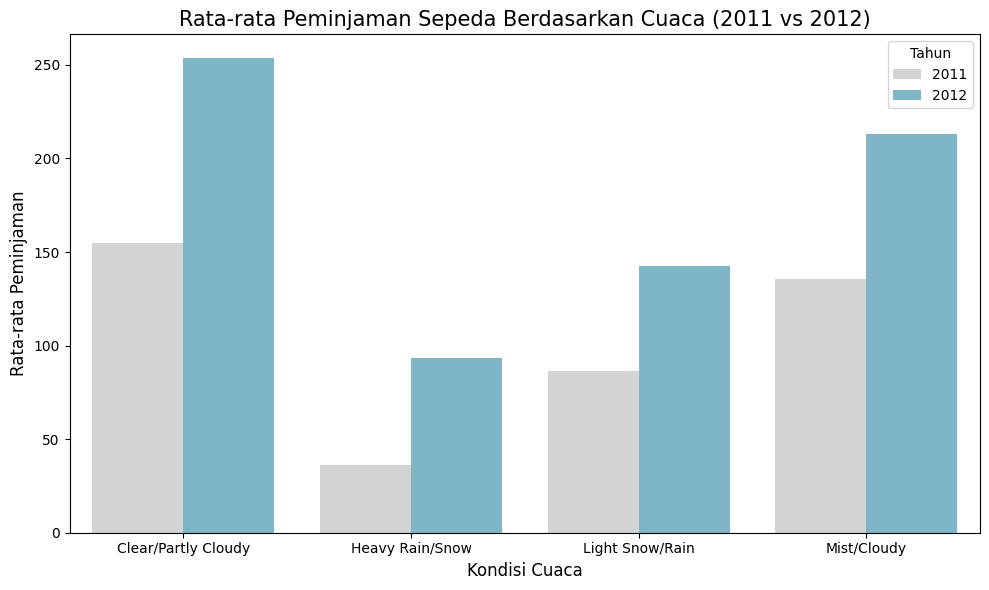

In [42]:
df = pd.read_csv("cleaned_hour.csv")
df['date'] = pd.to_datetime(df['date'])

# Visualisasi 1: Pertanyaan 1 - Pengaruh Cuaca dan Tahun terhadap Total Peminjaman
weather_summary = df.groupby(by=["year", "weather_condition"]).agg({
    "total_count": "mean"
}).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x="weather_condition",
    y="total_count",
    hue="year",
    data=weather_summary,
    palette=["#D3D3D3", "#72BCD4"]
)
plt.title("Rata-rata Peminjaman Sepeda Berdasarkan Cuaca (2011 vs 2012)", fontsize=15)
plt.ylabel("Rata-rata Peminjaman", fontsize=12)
plt.xlabel("Kondisi Cuaca", fontsize=12)
plt.legend(title="Tahun")
plt.tight_layout()
plt.show()

### Pertanyaan 2:

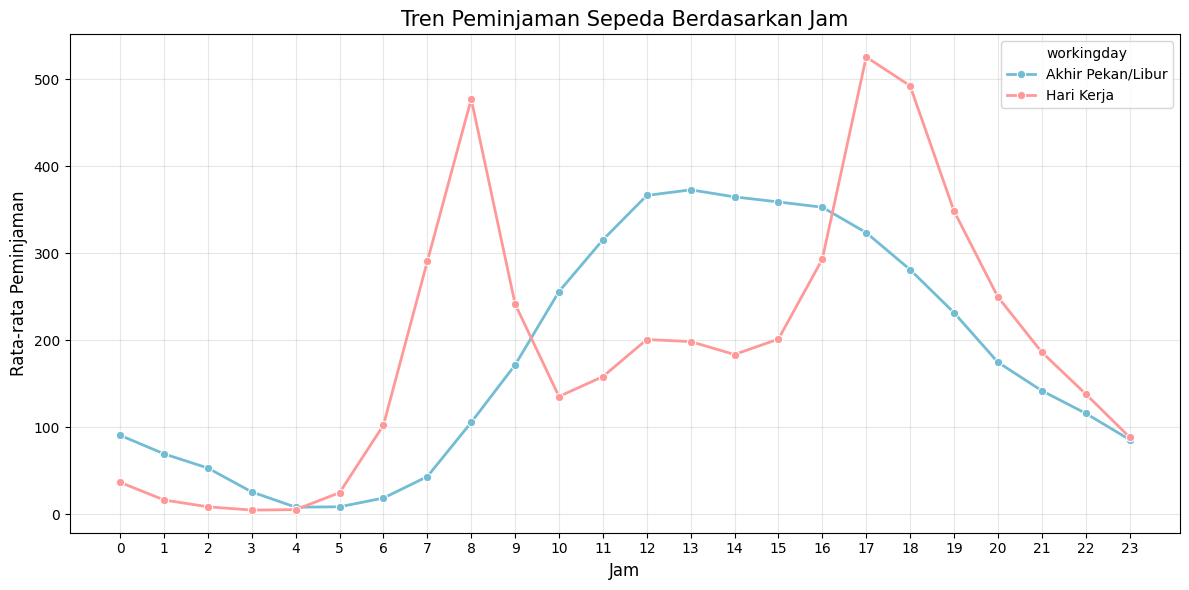

In [43]:
# Visualisasi 2: Pertanyaan 2 - Tren Peminjaman Berdasarkan Jam (Hari Kerja vs Libur)
hour_summary = df.groupby(by=["workingday", "hour"]).agg({
    "total_count": "mean"
}).reset_index()

hour_summary['workingday'] = hour_summary['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})

plt.figure(figsize=(12, 6))
sns.lineplot(
    x="hour",
    y="total_count",
    hue="workingday",
    data=hour_summary,
    marker="o",
    linewidth=2,
    palette=["#72BCD4", "#FF9999"]
)
plt.title("Tren Peminjaman Sepeda Berdasarkan Jam", fontsize=15)
plt.ylabel("Rata-rata Peminjaman", fontsize=12)
plt.xlabel("Jam", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**

Visualisasi Bar Chart (diagram batang) di atas menunjukkan perbandingan rata-rata peminjaman sepeda berdasarkan 4 kondisi cuaca, yang dikelompokkan berdasarkan tahun (Abu-abu untuk 2011, Biru untuk 2012).

Visualisasi Line Chart (diagram garis) ini sangat efektif untuk menunjukkan tren time-series (berdasarkan jam dalam sehari). Garis biru mewakili Hari Kerja, sedangkan garis merah muda mewakili Akhir Pekan/Libur.

## Analisis Lanjutan (Opsional)

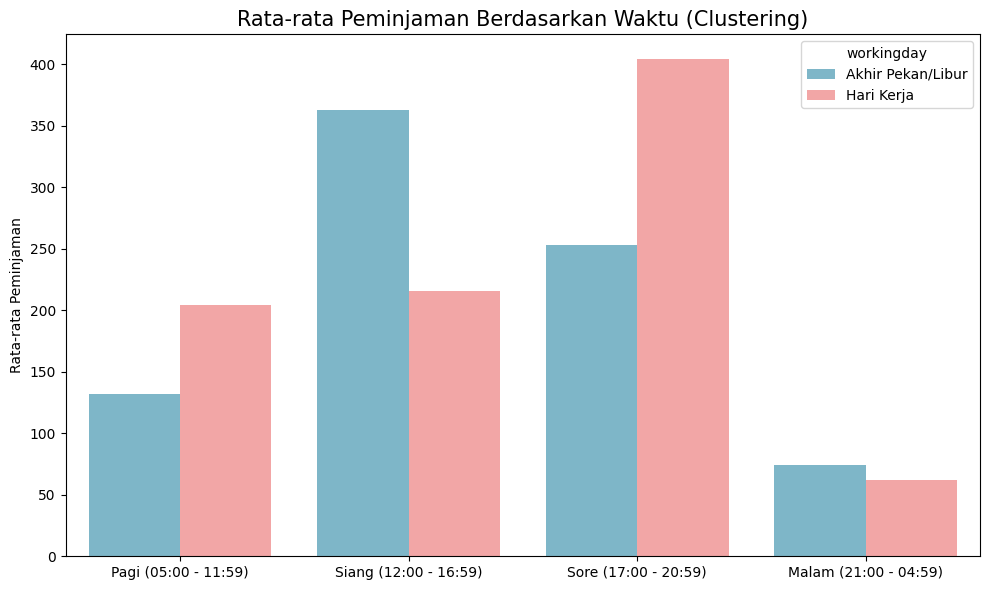

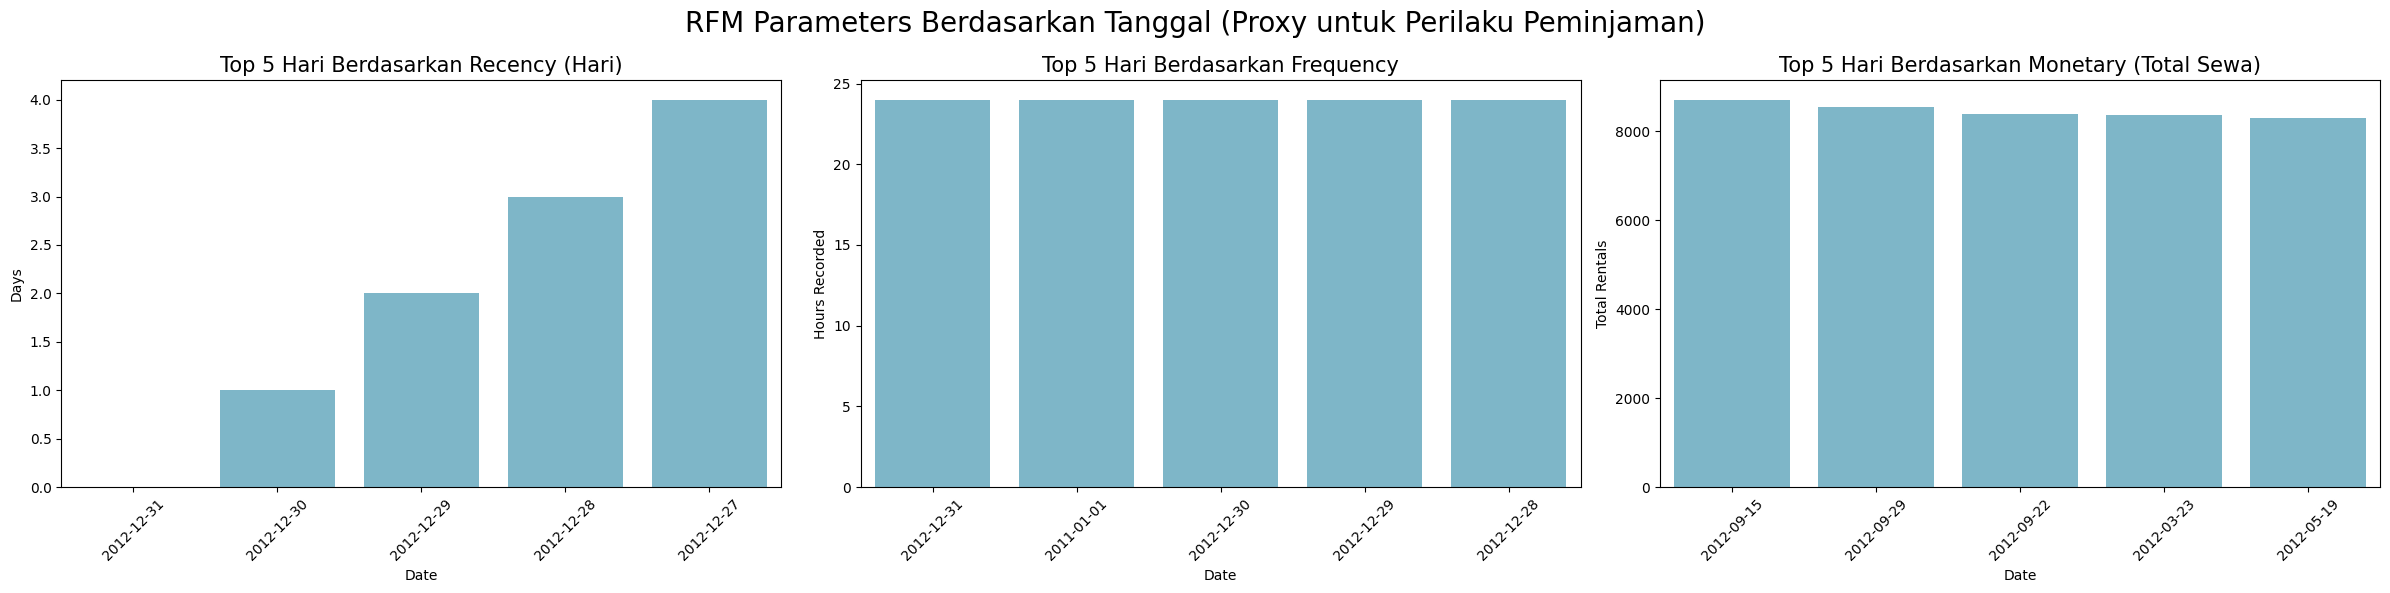

In [44]:
# Advanced Analysis: Clustering (Binning) Waktu
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Pagi (05:00 - 11:59)'
    elif 12 <= hour < 17:
        return 'Siang (12:00 - 16:59)'
    elif 17 <= hour < 21:
        return 'Sore (17:00 - 20:59)'
    else:
        return 'Malam (21:00 - 04:59)'

df['time_of_day'] = df['hour'].apply(get_time_of_day)

time_cluster_summary = df.groupby(by=["workingday", "time_of_day"]).agg({
    "total_count": "mean"
}).reset_index()
time_cluster_summary['workingday'] = time_cluster_summary['workingday'].map({1: 'Hari Kerja', 0: 'Akhir Pekan/Libur'})
time_cluster_summary['time_of_day'] = pd.Categorical(time_cluster_summary['time_of_day'], categories=['Pagi (05:00 - 11:59)', 'Siang (12:00 - 16:59)', 'Sore (17:00 - 20:59)', 'Malam (21:00 - 04:59)'], ordered=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    x="time_of_day",
    y="total_count",
    hue="workingday",
    data=time_cluster_summary,
    palette=["#72BCD4", "#FF9999"]
)
plt.title("Rata-rata Peminjaman Berdasarkan Waktu (Clustering)", fontsize=15)
plt.ylabel("Rata-rata Peminjaman")
plt.xlabel(None)
plt.tight_layout()
plt.show()


# Format the dates for display
rfm_df['date_str'] = rfm_df['date'].dt.strftime('%Y-%m-%d')

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(24, 6))
colors = ["#72BCD4"] * 5

# Recency (Most recent 5 days)
sns.barplot(y="recency", x="date_str", hue="date_str", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0], legend=False)
ax[0].set_title("Top 5 Hari Berdasarkan Recency (Hari)", fontsize=15)
ax[0].set_ylabel("Days")
ax[0].set_xlabel("Date")
ax[0].tick_params(axis='x', rotation=45)

# Frequency (Days with most hours recorded)
sns.barplot(y="frequency", x="date_str", hue="date_str", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1], legend=False)
ax[1].set_title("Top 5 Hari Berdasarkan Frequency", fontsize=15)
ax[1].set_ylabel("Hours Recorded")
ax[1].set_xlabel("Date")
ax[1].tick_params(axis='x', rotation=45)

# Monetary (Days with highest total rentals)
sns.barplot(y="monetary", x="date_str", hue="date_str", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2], legend=False)
ax[2].set_title("Top 5 Hari Berdasarkan Monetary (Total Sewa)", fontsize=15)
ax[2].set_ylabel("Total Rentals")
ax[2].set_xlabel("Date")
ax[2].tick_params(axis='x', rotation=45)

plt.suptitle("RFM Parameters Berdasarkan Tanggal (Proxy untuk Perilaku Peminjaman)", fontsize=20)
plt.tight_layout()
plt.show()

## Conclusion

**Pertanyaan Bisnis 1: Bagaimana pengaruh kondisi cuaca (weathersit) terhadap jumlah total peminjaman sepeda (cnt) pada tahun 2012 dibandingkan 2011?**

Explanatory Analysis:

Cuaca memiliki pengaruh yang sangat signifikan terhadap perilaku pengguna. Kondisi Clear/Partly Cloudy (Cerah) adalah kondisi paling ideal yang menghasilkan rata-rata peminjaman tertinggi (mencapai lebih dari 250 sepeda per jam di tahun 2012). Sebaliknya, ketika cuaca Heavy Rain/Snow (Hujan Lebat/Salju), rata-rata peminjaman anjlok drastis ke angka di bawah 100.

Insight Tambahan: Terdapat pertumbuhan bisnis yang pesat dari tahun 2011 ke 2012, dibuktikan dengan batang biru yang selalu lebih tinggi dari batang abu-abu di semua kondisi cuaca.


**Pertanyaan Bisnis 2: Pada jam berapa terjadi lonjakan peminjaman sepeda tertinggi pada hari kerja dibandingkan hari libur/akhir pekan?**

Explanatory Analysis:

Pada hari kerja, terjadi dua lonjakan ekstrem (puncak) yang membentuk pola bimodal. Puncak pertama terjadi pada Jam 08:00 pagi dan puncak tertinggi terjadi pada Jam 17:00 hingga 18:00 sore. Ini mengindikasikan bahwa sepeda mayoritas digunakan oleh komuter untuk pergi dan pulang kantor/sekolah.

Sebaliknya, pada akhir pekan (garis merah muda), polanya menyerupai bukit tunggal. Peminjaman mulai naik perlahan sejak pagi dan stabil di puncaknya pada tengah hari hingga sore (12:00 - 16:00), yang mengindikasikan penggunaan untuk rekreasi atau olahraga.


**Explanatory Clustering (Binning) Waktu Secara Manual:**

Dari visualisasi ini, pesannya menjadi jauh lebih sederhana untuk ditangkap oleh audiens bisnis. Di hari kerja (Biru), Sore hari adalah segmen paling krusial. Namun, jika ini adalah hari libur (Merah Muda), operasional harus difokuskan pada pemeliharaan stok sepeda di rentang waktu Siang.

**Explanatory RFM Analysis:**

- Recency: Menunjukkan hari-hari terakhir data direkam (karena kita mengambil top 5 ascending, ini menunjukkan tanggal di penghujung Desember 2012).

- Frequency: Menunjukkan kelengkapan data perekaman jam per harinya (semua hari rata-rata terekam penuh selama 24 jam).

- Monetary: Pada grafik ketiga (kanan), parameter Monetary dihitung dari total jumlah sepeda yang disewa (cnt). Tanggal 2012-09-15 dan 2012-09-29 merupakan hari dengan "Monetary" (total penyewaan) tertinggi sepanjang sejarah dataset (lebih dari 8.000 sepeda/hari).



**Berdasarkan data:**

Kita perlu memastikan kondisi sepeda selalu prima dan tersedia dalam jumlah banyak menjelang pukul 08:00 pagi dan 17:00 sore di setiap hari kerja.

Promosi dan marketing campaign sebaiknya digencarkan saat cuaca cerah di akhir pekan (antara pukul 12:00 - 16:00) untuk menarik lebih banyak casual user.